# Stock Return Predictor
## Notebook 4: Backtesting

**Project:** Predicting whether a stock will outperform the S&P 500 over the next month  
**Author:** Your Name  
**Date:** April 2026  

---

### Objective
Simulate how a trading strategy based on our model's predictions would have performed 
historically. We compare our strategy's returns against simply holding SPY (the S&P 500 
ETF) as a benchmark.

### Contents
1. Imports & Setup
2. Load Data
3. Build Strategy
4. Calculate Returns
5. Performance Metrics
6. Visualize Results

## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.linear_model import RidgeClassifier
from sklearn.preprocessing import StandardScaler

## 2. Load Data

In [2]:
DATA_DIR = "../data"

combined_df = pd.read_csv(f"{DATA_DIR}/features.csv", index_col=0, parse_dates=True)
prices_df   = pd.read_csv(f"{DATA_DIR}/prices.csv",   index_col=0, parse_dates=True)

print(f"Features shape: {combined_df.shape}")
print(f"Prices shape:   {prices_df.shape}")

Features shape: (77, 140)
Prices shape:   (1760, 20)


In [3]:
import yfinance as yf

# Pull SPY for benchmark
spy_raw      = yf.download("SPY", start="2018-01-01", end="2024-12-31", auto_adjust=True)
spy_monthly  = spy_raw["Close"].resample("ME").last()
spy_returns  = spy_monthly.pct_change().dropna()

spy_returns.head()

[*********************100%***********************]  1 of 1 completed


Ticker,SPY
Date,
2018-02-28,-0.036360
2018-03-31,-0.027411
2018-04-30,0.005168
2018-05-31,0.024310
2018-06-30,0.005751


## 3. Build Strategy
We use a rolling window approach:
- Train on all data up to month T
- Predict which stocks will beat SPY in month T+1
- Buy the top 5 predicted stocks equally weighted
- Move forward one month and repeat

This avoids lookahead bias as we never train on future data.

In [4]:
TICKERS = [
    "AAPL", "MSFT", "GOOGL", "AMZN", "META",
    "JPM", "GS", "BAC", "WFC", "C",
    "XOM", "CVX", "COP", "SLB", "EOG",
    "JNJ", "PFE", "UNH", "MRK", "ABT"
]

FEATURE_COLS = ["ret_1m", "ret_3m", "ret_6m", "ma_ratio_20", "ma_ratio_50", "volatility"]

# Stack into long format — same as notebook 3
rows = []
for ticker in TICKERS:
    feature_names = [f"{ticker}_{f}" for f in FEATURE_COLS]
    target_name   = f"{ticker}_target"
    if not all(c in combined_df.columns for c in feature_names + [target_name]):
        continue
    temp = combined_df[feature_names + [target_name]].copy()
    temp.columns = FEATURE_COLS + ["target"]
    temp["ticker"] = ticker
    rows.append(temp)

model_df = pd.concat(rows).sort_index()
print(f"Model dataframe shape: {model_df.shape}")

Model dataframe shape: (1540, 8)


In [5]:
# Rolling window backtest
dates = model_df.index.unique().sort_values()
MIN_TRAIN_MONTHS = 24  # need at least 24 months of data before first prediction

strategy_returns = {}

for i in range(MIN_TRAIN_MONTHS, len(dates) - 1):
    train_date  = dates[i]
    future_date = dates[i + 1]

    # Train on everything up to current date
    train = model_df[model_df.index <= train_date]
    X_train = train[FEATURE_COLS]
    y_train = train["target"]

    if y_train.nunique() < 2:
        continue

    # Scale and fit
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)

    model = RidgeClassifier(alpha=1.0)
    model.fit(X_train_scaled, y_train)

    # Predict for current month — one row per ticker
    current = model_df[model_df.index == train_date]
    if current.empty:
        continue

    X_current = scaler.transform(current[FEATURE_COLS])
    current = current.copy()
    current["score"] = model.decision_function(X_current)

    # Pick top 5 stocks by score
    top5 = current.nlargest(5, "score")["ticker"].values
    strategy_returns[future_date] = top5

print(f"Months with predictions: {len(strategy_returns)}")
print(f"Sample prediction: {list(strategy_returns.items())[0]}")

Months with predictions: 52
Sample prediction: (Timestamp('2020-08-31 00:00:00'), <StringArray>
['AMZN', 'AAPL', 'META', 'MSFT', 'UNH']
Length: 5, dtype: str)


## 4. Calculate Returns
For each month, calculate the equal-weighted return of our top 5 picks
and compare to SPY.

In [6]:
# Monthly prices for return calculation
monthly_prices = prices_df.resample("ME").last()
monthly_returns = monthly_prices.pct_change()

portfolio_returns = {}

for date, tickers in strategy_returns.items():
    if date not in monthly_returns.index:
        continue
    # Equal weight the top 5 picks
    rets = [monthly_returns.loc[date, t] for t in tickers if t in monthly_returns.columns]
    if rets:
        portfolio_returns[date] = np.mean(rets)

portfolio_series = pd.Series(portfolio_returns).sort_index()
spy_aligned      = spy_returns.reindex(portfolio_series.index).dropna()
portfolio_series = portfolio_series.reindex(spy_aligned.index)

print(f"Backtest months: {len(portfolio_series)}")
print(f"Portfolio mean monthly return: {portfolio_series.mean():.4f}")

# Extract SPY scalar values
spy_values = spy_aligned.values.flatten()
print(f"SPY mean monthly return:       {spy_values.mean():.4f}")

Backtest months: 52
Portfolio mean monthly return: 0.0261
SPY mean monthly return:       0.0142


## 5. Performance Metrics

In [8]:
# Cumulative returns
portfolio_cumulative = (1 + portfolio_series).cumprod()
spy_cumulative       = (1 + spy_aligned).cumprod()

# Total return
portfolio_total = float(portfolio_cumulative.iloc[-1])  - 1
spy_total       = float(spy_cumulative.iloc[-1].item()) - 1

# Annualized return
n_months = len(portfolio_series)
portfolio_annual = (1 + portfolio_total) ** (12 / n_months) - 1
spy_annual       = (1 + spy_total)       ** (12 / n_months) - 1

# Sharpe ratio (monthly, annualized, assuming 0 risk-free rate for simplicity)
portfolio_sharpe = (portfolio_series.mean() / portfolio_series.std()) * np.sqrt(12)
spy_sharpe       = (spy_aligned.values.flatten().mean() / spy_aligned.values.flatten().std()) * np.sqrt(12)

# Max drawdown
def max_drawdown(cum_returns):
    rolling_max = cum_returns.cummax()
    drawdown     = (cum_returns - rolling_max) / rolling_max
    return drawdown.min()

portfolio_dd = max_drawdown(portfolio_cumulative)
spy_dd       = float(max_drawdown(spy_cumulative).item())

# Summary table
metrics = pd.DataFrame({
    "Metric": ["Total Return", "Annualized Return", "Sharpe Ratio", "Max Drawdown"],
    "Strategy": [
        f"{portfolio_total:.2%}",
        f"{portfolio_annual:.2%}",
        f"{portfolio_sharpe:.3f}",
        f"{portfolio_dd:.2%}"
    ],
    "SPY": [
        f"{spy_total:.2%}",
        f"{spy_annual:.2%}",
        f"{spy_sharpe:.3f}",
        f"{spy_dd:.2%}"
    ]
})

print(metrics.to_string(index=False))

           Metric Strategy     SPY
     Total Return  238.45%  96.35%
Annualized Return   32.49%  16.85%
     Sharpe Ratio    1.275   1.035
     Max Drawdown  -17.73% -23.93%


## 6. Visualize Results

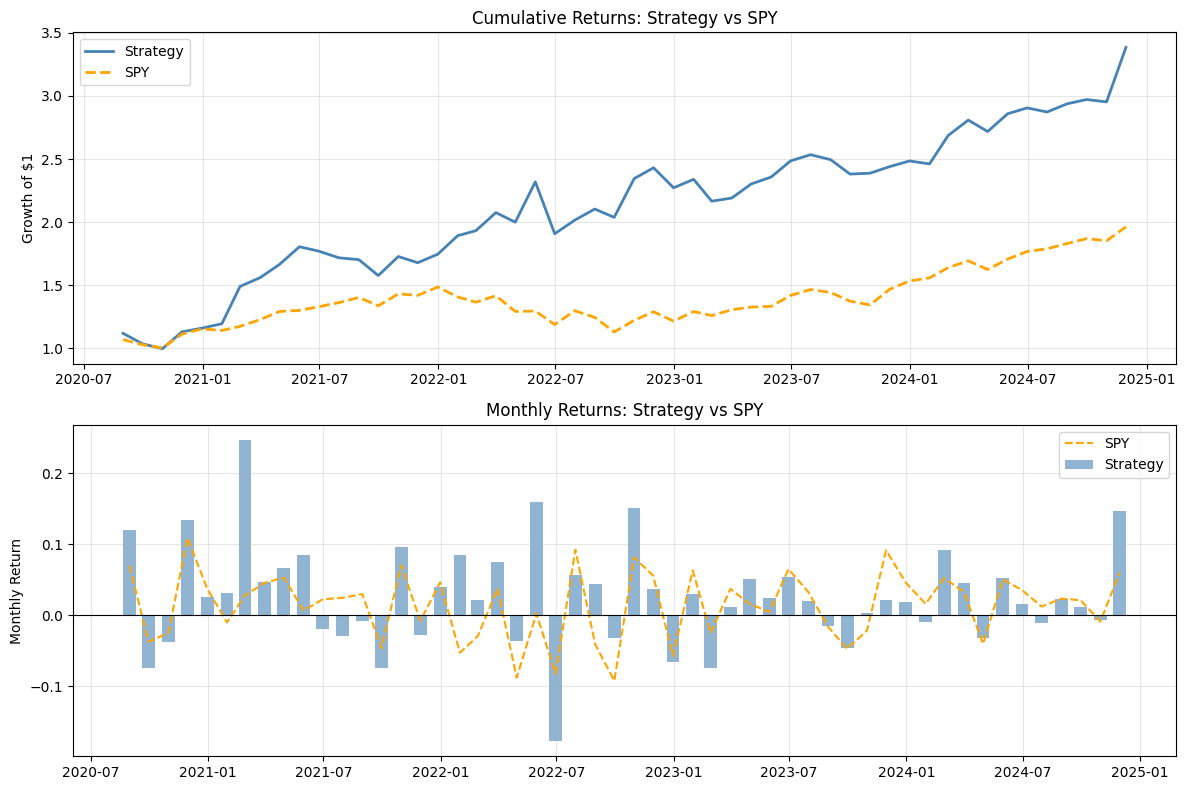

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Plot 1 — Cumulative returns
axes[0].plot(portfolio_cumulative.index, portfolio_cumulative.values, 
             label="Strategy", color="steelblue", linewidth=2)
axes[0].plot(spy_cumulative.index, spy_cumulative.values.flatten(),
             label="SPY", color="orange", linewidth=2, linestyle="--")
axes[0].set_title("Cumulative Returns: Strategy vs SPY")
axes[0].set_ylabel("Growth of $1")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot 2 — Monthly returns comparison
axes[1].bar(portfolio_series.index, portfolio_series.values, 
            label="Strategy", color="steelblue", alpha=0.6, width=20)
axes[1].plot(spy_aligned.index, spy_aligned.values.flatten(),
             label="SPY", color="orange", linewidth=1.5, linestyle="--")
axes[1].set_title("Monthly Returns: Strategy vs SPY")
axes[1].set_ylabel("Monthly Return")
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()